# Student Performance Indicator

## Life cycle of Machine Learning Project
- Understanding the problem statement
- Data collections
- Data checks to perform
- Exploratory Data Analysis
- Data Pre-Processing
- Model Training
- Choose best model

## 1) Problem Statement
- This project understands how the student's performance (test scores) is affected by other variables such as Gender, Ethinicity, Parental level of education, Lunch and Test preparation course.

## 2) Data Collection
- Dataset Source - https://www.kaggle.com/datasets/spscientist/students-performance-in-exams?datasetId=74977
- The data consists of 8 column and 1000 rows.

### 2.1 Import Data and Required Packages
#### Importing Pandas, Numpy, Matplotlib, Seaborn and Warings Library.

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

#### Import the CSV Data as Pandas DataFrame

In [3]:
df = pd.read_csv('data/stud.csv')

#### Show Top 5 Records

In [6]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


#### Shape of the dataset

In [4]:
df.shape

(1000, 8)

### 2.2 Dataset information

- gender : sex of students -> (Male/female)
- race/ethnicity : ethnicity of students -> (Group A, B,C, D,E)
- parental level of education : parents' final education ->(bachelor's degree,some college,master's degree,associate's degree,high school)
- lunch : having lunch before test (standard or free/reduced)
- test preparation course : complete or not complete before test
- math score
- reading score
- writing score

## 3. Data Checks to perform
- Check Missing values
- Check Duplicates
- Check data type
- Check the number of unique values of each column
- Check statistics of data set
- Check various categories present in the different categorical column

### 3.1 Check Missing values

In [7]:
df.isna().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

##### There are no missing values in the data set

### 3.2 Check Duplicates

In [9]:
df.duplicated().sum()

np.int64(0)

##### There are no duplicate values

### 3.3 Check data types

In [10]:
# Check Null and Dtypes
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


### 3.4 Checking the number of unique values of each column

In [11]:
df.nunique()

gender                          2
race/ethnicity                  5
parental level of education     6
lunch                           2
test preparation course         2
math score                     81
reading score                  72
writing score                  77
dtype: int64

### 3.5 Check statistics of data set

In [12]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


#### Insight
- From above description of numerical data, all means are very close to each other - between 66 and 68.05;
- All standard deviations are also close - between 14.6 and 15.19;
- While there is a minimum score 0 for math, for writing minimum is much higher = 10 and for reading myet higher = 17

### 3.7 Exploring Data

In [138]:
df.rename(columns={
    "gender": "gender",
    "race/ethnicity": "race_ethnicity",
    "parental level of education": "parent_education",
    "lunch": "lunch_type",
    "test preparation course": "test_prep_course",
    "math score": "math_score",
    "reading score": "reading_score",
    "writing score": "writing_score"
}, inplace=True)
df.to_csv('data/stud1.csv')
df.head()

,gender,race_ethnicity,parent_education,lunch_type,test_prep_course,math_score,reading_score,writing_score,total_score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [27]:
print("Categories in 'gender' variable:     ",end=" ")
print(df['gender'].unique().tolist())

print("Categories in 'race_ethnicity' variable:  ",end=" ")
print(df['race_ethnicity'].unique().tolist())

print("Categories in'parent_education' variable:",end=" " )
print(df['parent_education'].unique().tolist())

print("Categories in 'lunch_type' variable:     ",end=" " )
print(df['lunch_type'].unique().tolist())

print("Categories in 'test_prep_course' variable:     ",end=" " )
print(df['test_prep_course'].unique().tolist())

Categories in 'gender' variable:      ['female', 'male']
Categories in 'race_ethnicity' variable:   ['group B', 'group C', 'group A', 'group D', 'group E']
Categories in'parent_education' variable: ["bachelor's degree", 'some college', "master's degree", "associate's degree", 'high school', 'some high school']
Categories in 'lunch_type' variable:      ['standard', 'free/reduced']
Categories in 'test_prep_course' variable:      ['none', 'completed']


In [32]:
# define numerical and categorical columns
numeric_features = df.select_dtypes(include=['number']).columns.tolist()

categorical_features = df.select_dtypes(include=['object', 'string', 'category']).columns.tolist()

print(f"We have {len(numeric_features)} numerical features: {numeric_features}")
print(f"We have {len(categorical_features)} categorical features: {categorical_features}")

We have 3 numerical features: ['math_score', 'reading_score', 'writing_score']
We have 5 categorical features: ['gender', 'race_ethnicity', 'parent_education', 'lunch_type', 'test_prep_course']


In [33]:
df.head(2)

,gender,race_ethnicity,parent_education,lunch_type,test_prep_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88


### 3.8 Adding columns for "Total Score" and "Average"

In [35]:
df['total_score'] = df['math_score'] + df['reading_score'] + df['writing_score']
df['average'] = df['total_score']/3
df.head()

,gender,race_ethnicity,parent_education,lunch_type,test_prep_course,math_score,reading_score,writing_score,total_score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [45]:
reading_full = len(df[df['reading_score'] == 100])
writing_full = len(df[df['writing_score'] == 100])
math_full = len(df[df['math_score'] == 100])

print(f'Number of students with full marks in Maths: {math_full}')
print(f'Number of students with full marks in Writing: {writing_full}')
print(f'Number of students with full marks in Reading: {reading_full}')

Number of students with full marks in Maths: 7
Number of students with full marks in Writing: 14
Number of students with full marks in Reading: 17


In [44]:
len(df[df['math_score'] == 100])

7

In [46]:
reading_less_20 = len(df[df['reading_score'] <= 20])
writing_less_20 = len(df[df['writing_score'] <= 20])
math_less_20 = len(df[df['math_score'] <= 20])

print(f'Number of students with less than 20 marks in Maths: {math_less_20}')
print(f'Number of students with less than 20 marks in Writing: {writing_less_20}')
print(f'Number of students with less than 20 marks in Reading: {reading_less_20}')

Number of students with less than 20 marks in Maths: 4
Number of students with less than 20 marks in Writing: 3
Number of students with less than 20 marks in Reading: 1


#### Insights
- From above values we get students have performed the worst in Maths
- Best performance is in reading section

## 4. Exploring Data ( Visualization )

### 4.1 Visualize average score distribution to make some conclusion.
- Histogram
- Kernel Distribution Function (KDE)

#### 4.1.1 Histogram & KDE

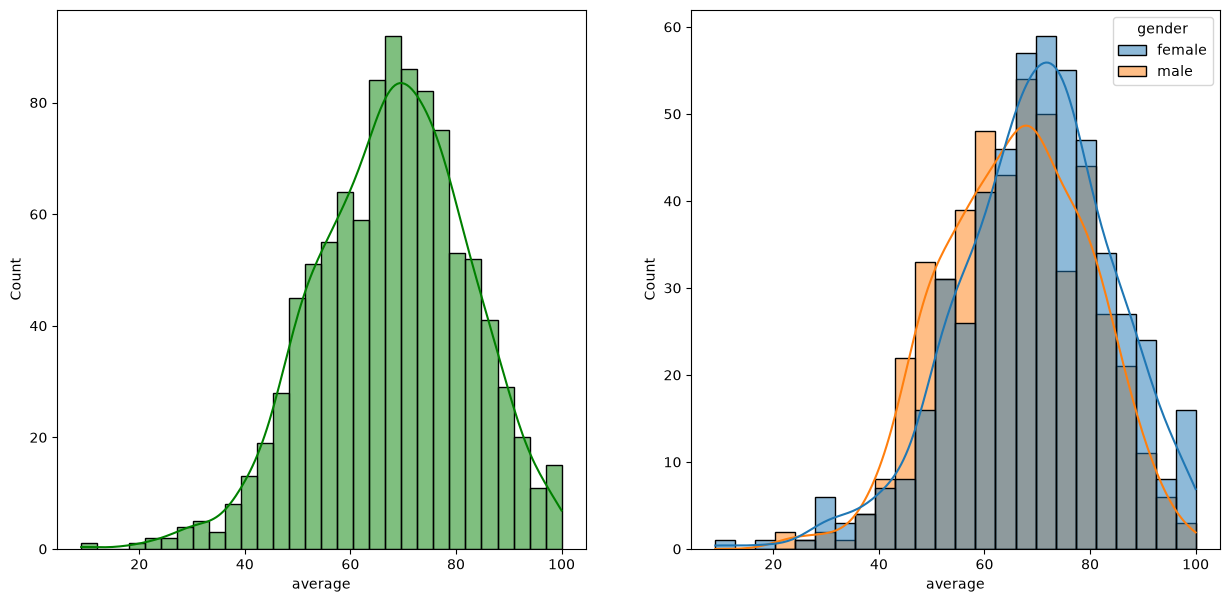

In [47]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))
plt.subplot(121)
sns.histplot(data=df,x='average',bins=30,kde=True,color='g')
plt.subplot(122)
sns.histplot(data=df,x='average',kde=True,hue='gender')
plt.show()

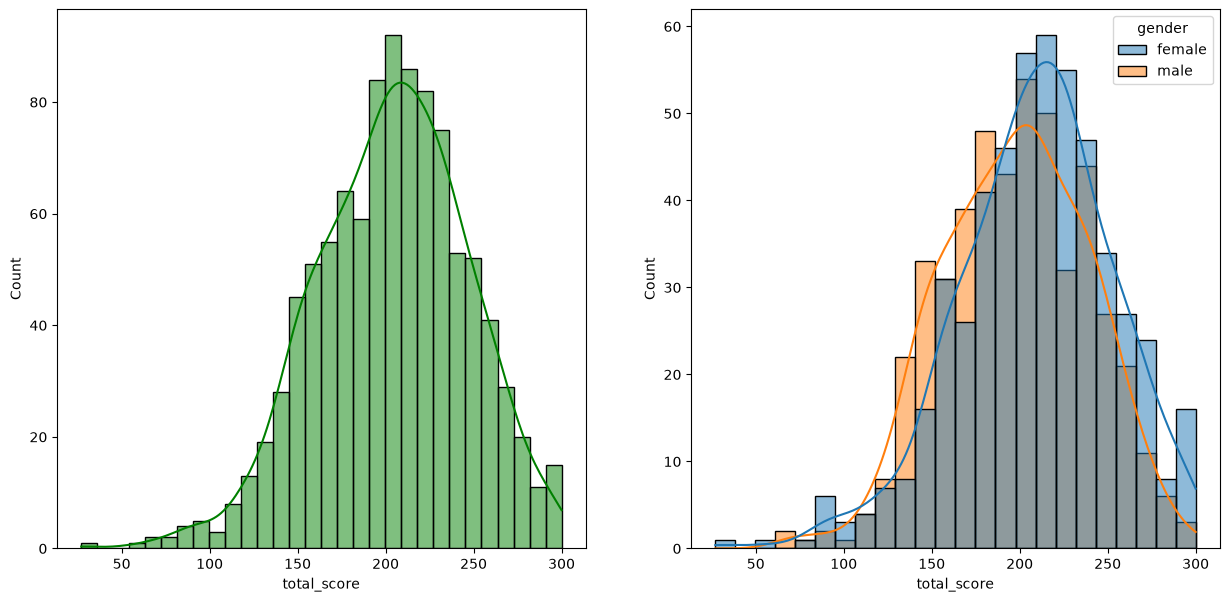

In [49]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))
plt.subplot(121)
sns.histplot(data=df,x='total_score',bins=30,kde=True,color='g')
plt.subplot(122)
sns.histplot(data=df,x='total_score',kde=True,hue='gender')
plt.show()

#### Insights
- Female students tend to perform well then male students.

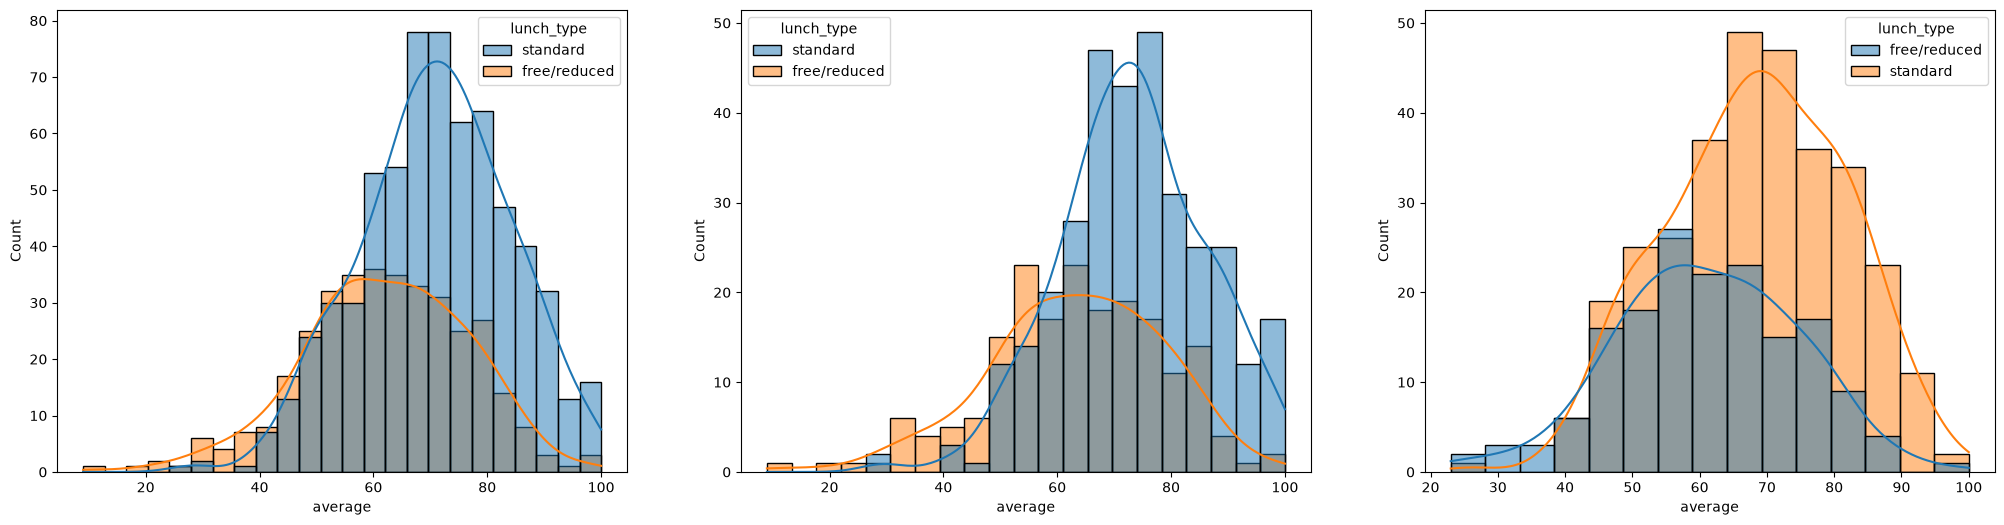

In [52]:
plt.subplots(1,3,figsize=(25,6))
plt.subplot(131)
sns.histplot(data=df,x='average',kde=True,hue='lunch_type')
plt.subplot(132)
sns.histplot(data=df[df.gender=='female'],x='average',kde=True,hue='lunch_type')
plt.subplot(133)
sns.histplot(data=df[df.gender=='male'],x='average',kde=True,hue='lunch_type')
plt.show()

#### Insights
- Standard lunch helps perform well in exams.
- Standard lunch helps perform well in exams be it a male or a female.

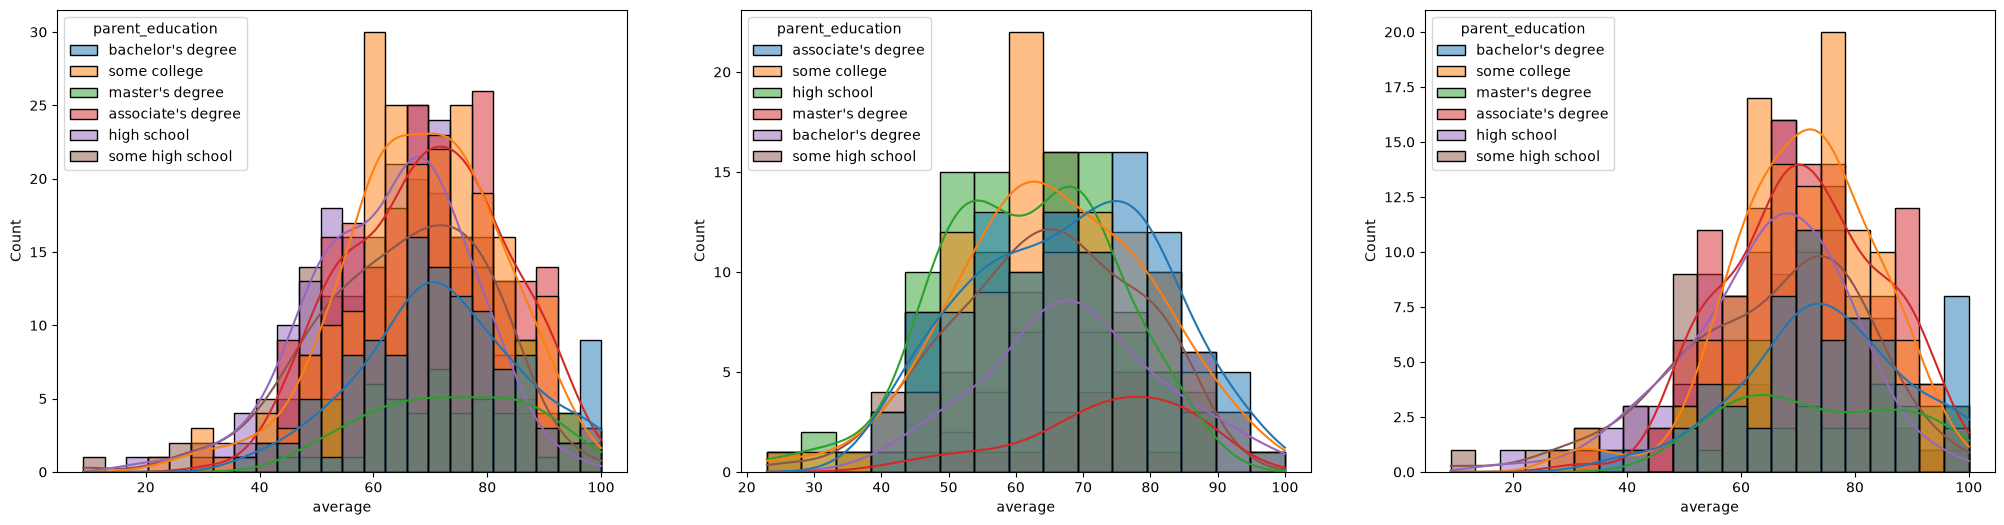

In [53]:
plt.subplots(1,3,figsize=(25,6))
plt.subplot(131)
ax =sns.histplot(data=df,x='average',kde=True,hue='parent_education')
plt.subplot(132)
ax =sns.histplot(data=df[df.gender=='male'],x='average',kde=True,hue='parent_education')
plt.subplot(133)
ax =sns.histplot(data=df[df.gender=='female'],x='average',kde=True,hue='parent_education')
plt.show()

#### Insights
- In general parent's education don't help student perform well in exam.
- 2nd plot shows that parent's whose education is of associate's degree or master's degree their male child tend to perform well in exam
- 3rd plot we can see there is no effect of parent's education on female students.

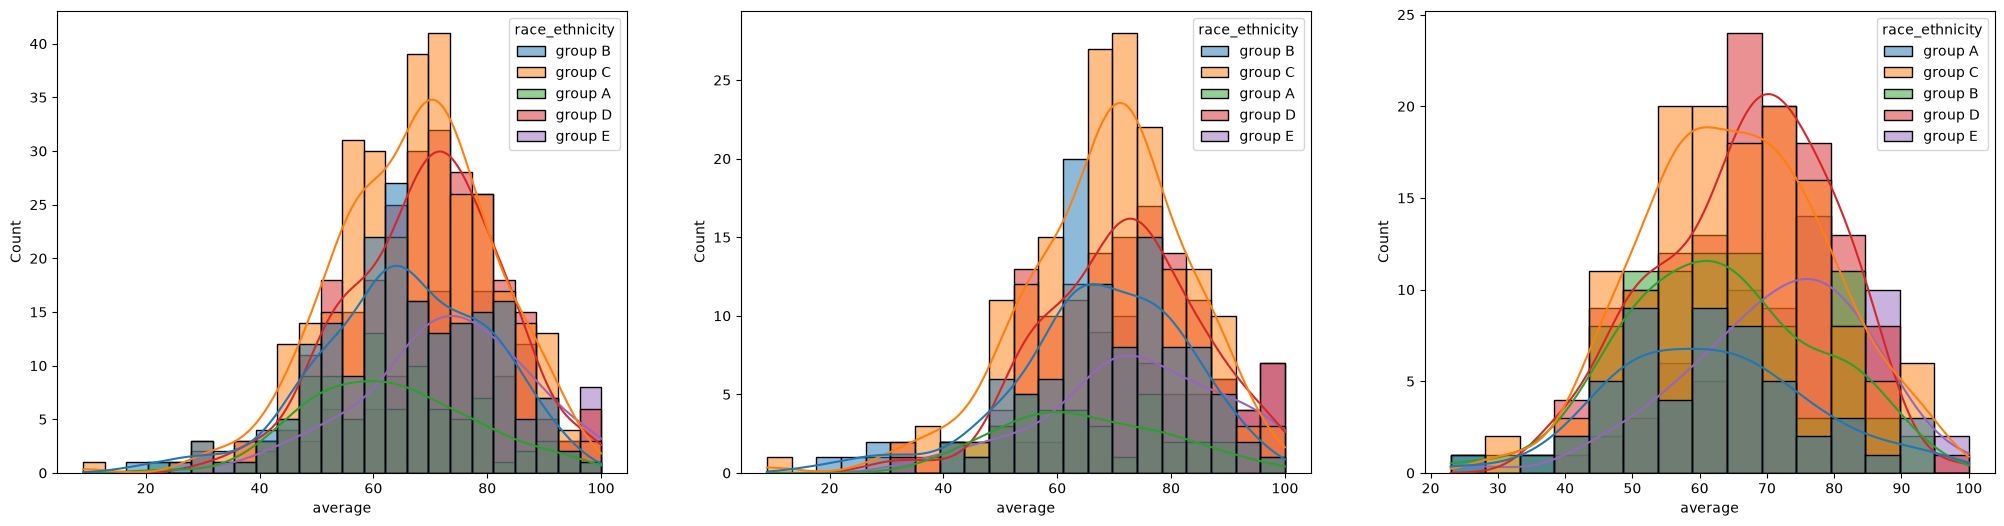

In [55]:
plt.subplots(1,3,figsize=(25,6))
plt.subplot(131)
ax =sns.histplot(data=df,x='average',kde=True,hue='race_ethnicity')
plt.subplot(132)
ax =sns.histplot(data=df[df.gender=='female'],x='average',kde=True,hue='race_ethnicity')
plt.subplot(133)
ax =sns.histplot(data=df[df.gender=='male'],x='average',kde=True,hue='race_ethnicity')
plt.show()

#### Insights
- Students of group A and group B tends to perform poorly in exam.
- Students of group A and group B tends to perform poorly in exam irrespective of whether they are male or female

### 4.2 Maximum score of students in all three subjects

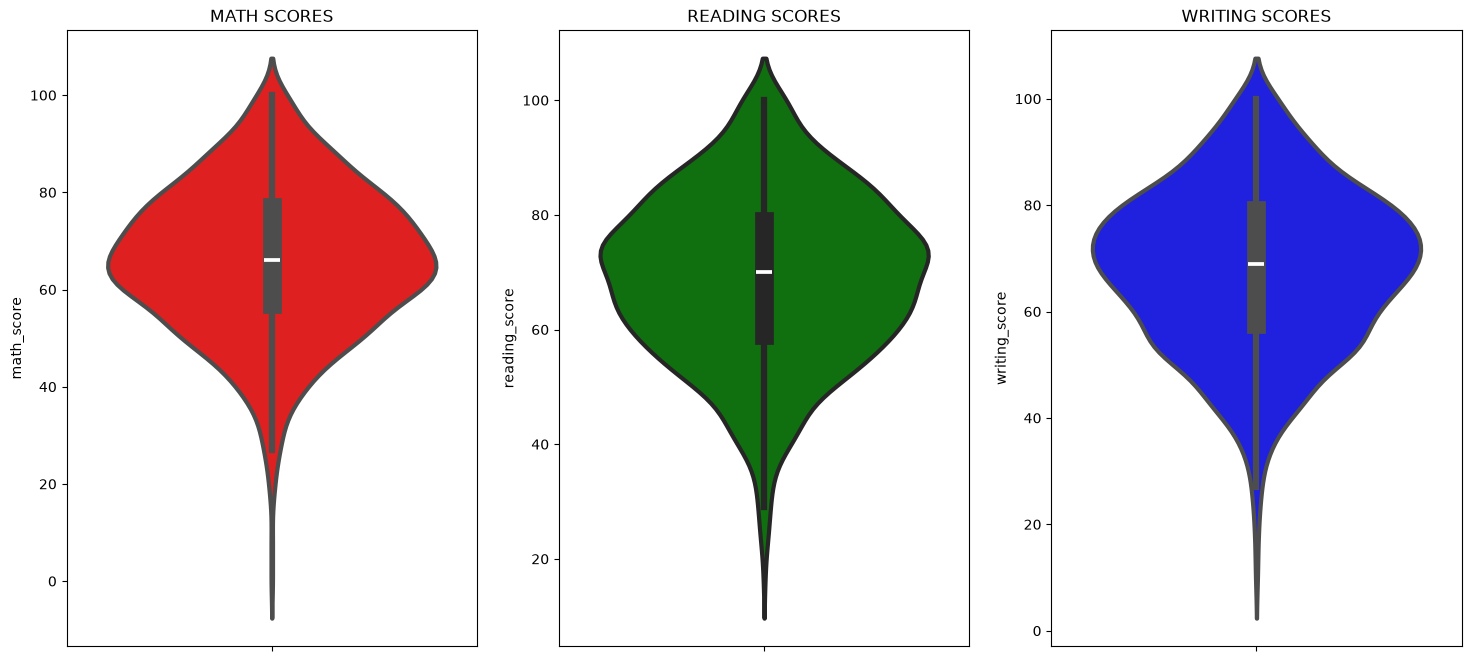

In [58]:
plt.figure(figsize=(18,8))
plt.subplot(1, 3, 1)
plt.title('MATH SCORES')
sns.violinplot(y='math_score',data=df,color='red',linewidth=3)
plt.subplot(1, 3, 2)
plt.title('READING SCORES')
sns.violinplot(y='reading_score',data=df,color='green',linewidth=3)
plt.subplot(1, 3, 3)
plt.title('WRITING SCORES')
sns.violinplot(y='writing_score',data=df,color='blue',linewidth=3)
plt.show()

#### Insights
- From the above three plots its clearly visible that most of the students score in between 60-80 in Maths whereas in reading and writing most of them score from 50-80

### 4.3 Multivariate analysis using pieplot

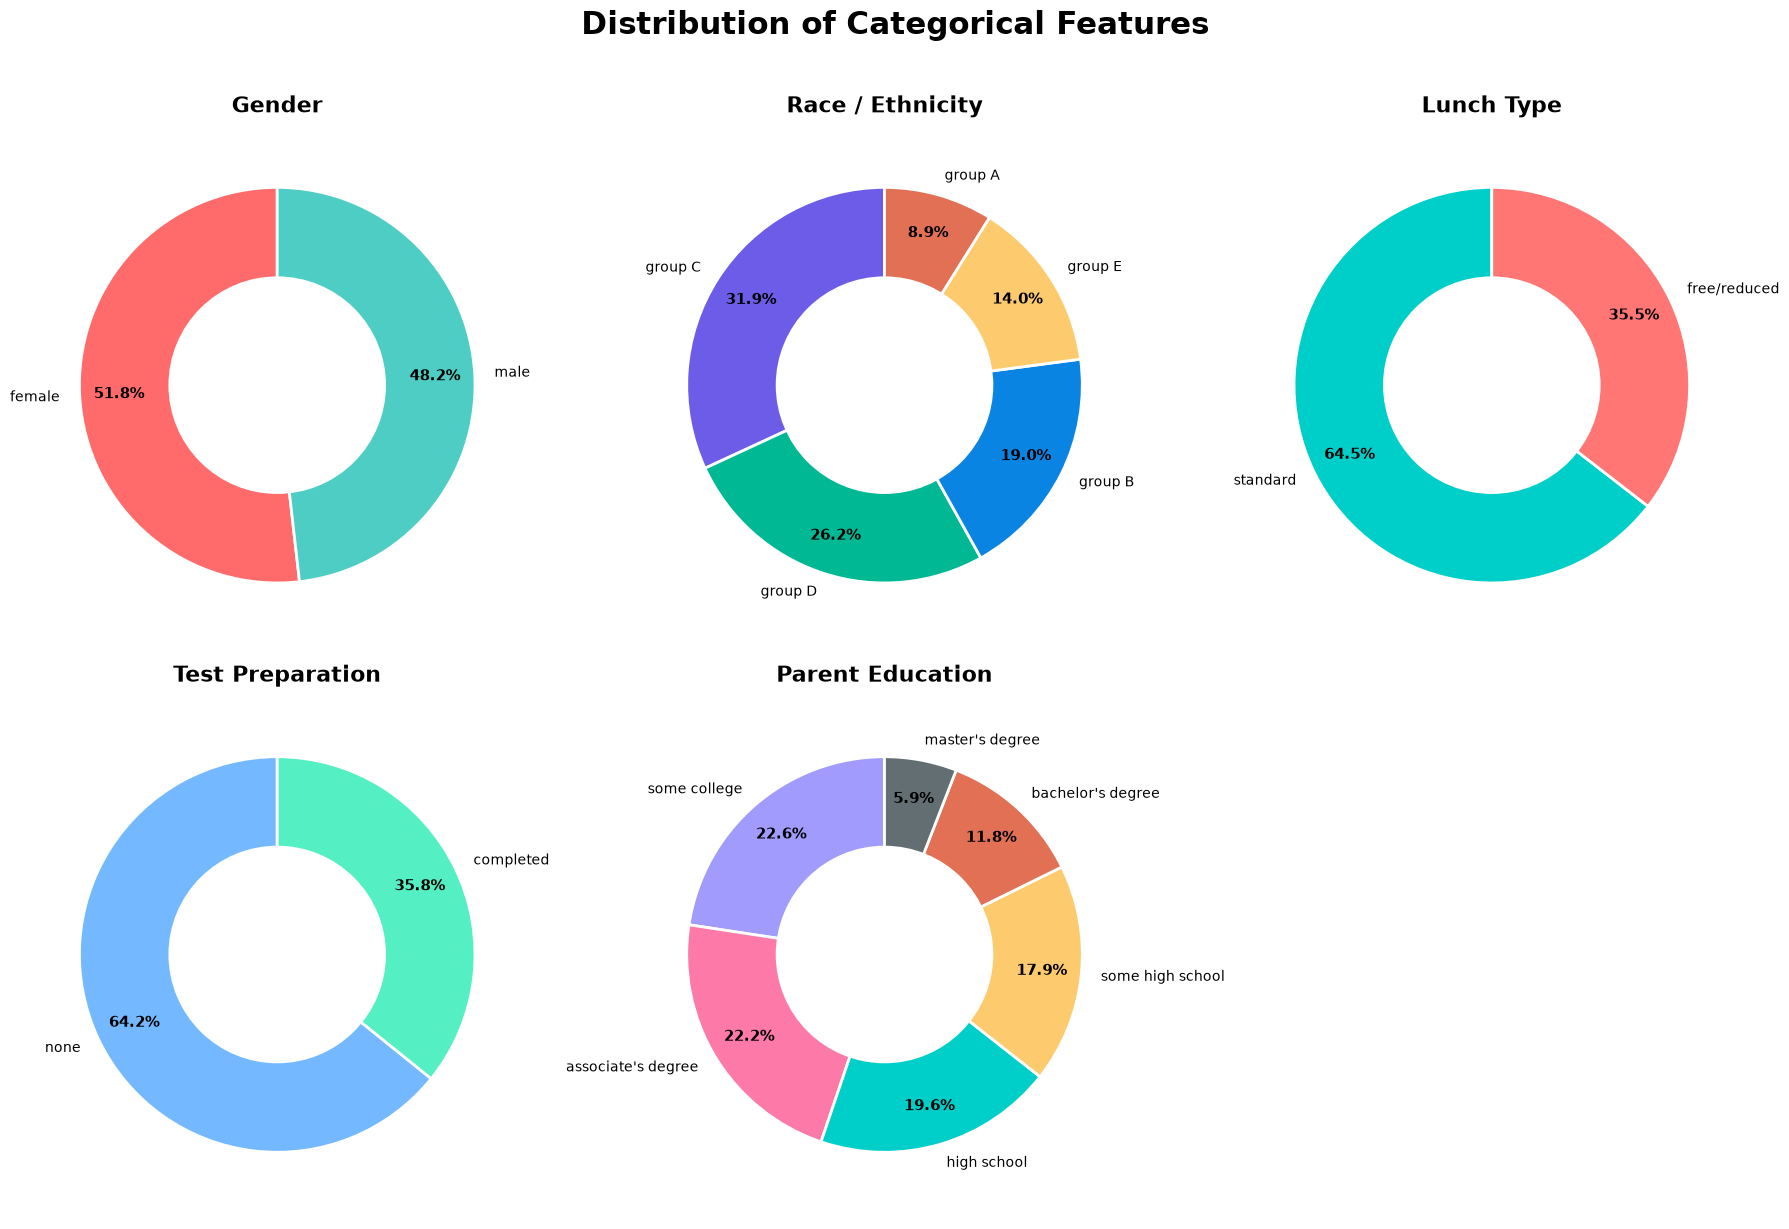

In [68]:
import matplotlib.pyplot as plt

# Figure size
plt.figure(figsize=(18, 12))

# Modern color palettes
colors = {
    "gender": ["#FF6B6B", "#4ECDC4"],
    "race": ["#6C5CE7", "#00B894", "#0984E3", "#FDCB6E", "#E17055"],
    "lunch": ["#00CEC9", "#FF7675"],
    "prep": ["#74B9FF", "#55EFC4"],
    "parent": ["#A29BFE", "#FD79A8", "#00CEC9", "#FDCB6E", "#E17055", "#636E72"]
}

plots = [
    (
        "gender",
        "Gender",
        colors["gender"]
    ),
    (
        "race_ethnicity",
        "Race / Ethnicity",
        colors["race"]
    ),
    (
        "lunch_type",
        "Lunch Type",
        colors["lunch"]
    ),
    (
        "test_prep_course",
        "Test Preparation",
        colors["prep"]
    ),
    (
        "parent_education",
        "Parent Education",
        colors["parent"]
    )
]

for i, (column, title, color) in enumerate(plots, start=1):

    plt.subplot(2, 3, i)

    counts = df[column].value_counts()

    wedges, texts, autotexts = plt.pie(
        counts,
        labels=counts.index,
        colors=color,
        autopct="%1.1f%%",
        startangle=90,
        pctdistance=0.8,
        wedgeprops=dict(edgecolor="white", linewidth=2)
    )

    # Create donut chart
    centre_circle = plt.Circle((0, 0), 0.55, fc="white")
    plt.gca().add_artist(centre_circle)

    # Style percentage text
    for autotext in autotexts:
        autotext.set_color("black")
        autotext.set_fontsize(11)
        autotext.set_weight("bold")

    plt.title(title, fontsize=16, fontweight="bold")
    plt.axis("equal")

plt.suptitle(
    "Distribution of Categorical Features",
    fontsize=22,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()
plt.show()

#### Insights
- Number of Male and Female students is almost equal
- Number of students are greatest in Group C
- Number of students who have standard lunch are greater
- Number of students who have not enrolled in any test preparation course is greater
- Number of students whose parental education is "Some College" is greater followed closely by "Associate's Degree"

### 4.4 Feature Wise Visualization
#### 4.4.1 GENDER COLUMN
- How is distribution of Gender ?
- Is gender has any impact on student's performance ?
#### UNIVARIATE ANALYSIS ( How is distribution of Gender ? )

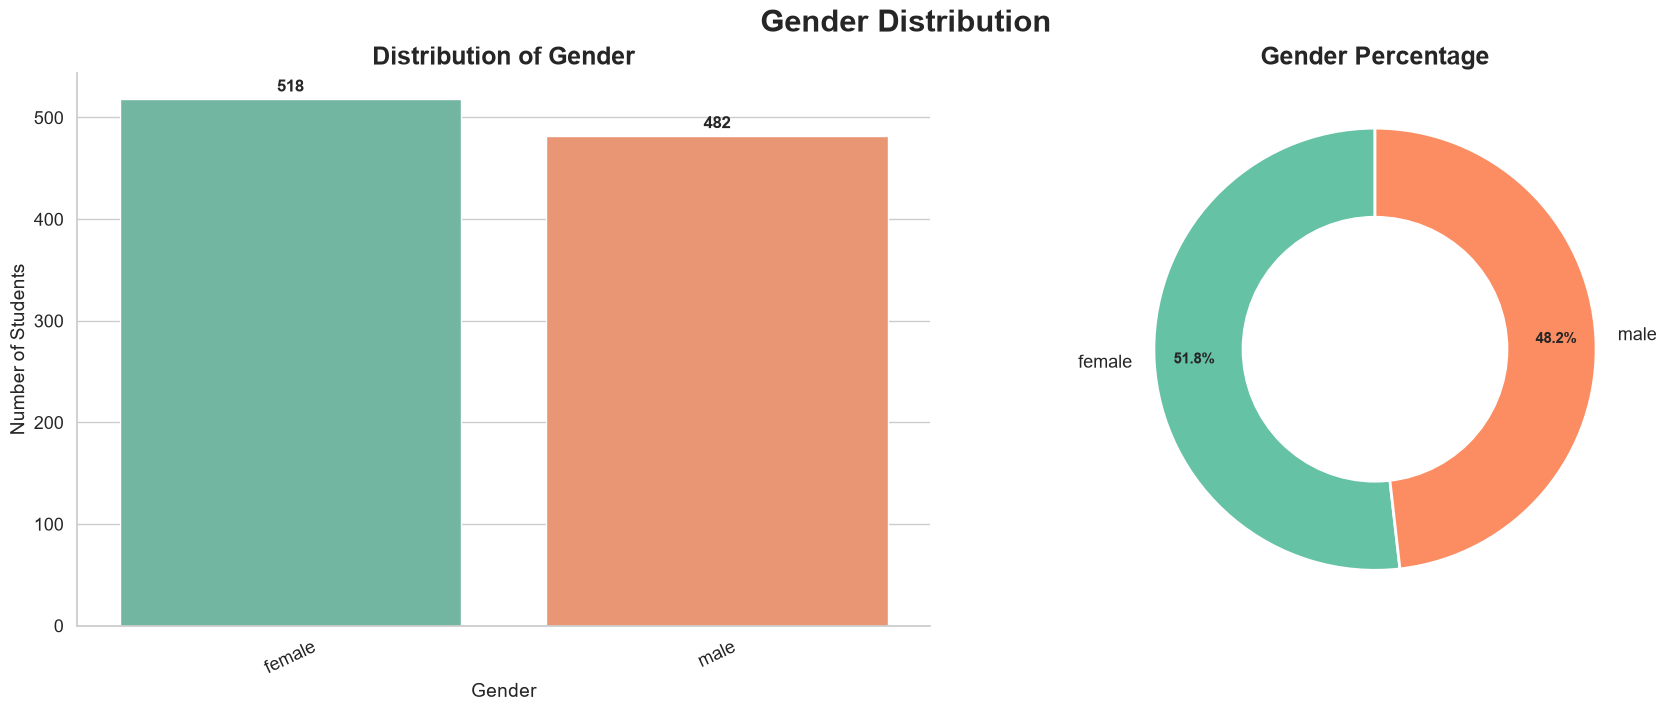

In [97]:
# Style
sns.set_theme(style="whitegrid", font_scale=1.2)

fig, ax = plt.subplots(1, 2, figsize=(18, 7), constrained_layout=True)

# -------------------------
# Count Plot
# -------------------------
counts = df["gender"].value_counts()

sns.countplot(
    data=df,
    x="gender",
    order=counts.index,
    palette="Set2",
    ax=ax[0]
)

ax[0].set_title("Distribution of Gender", fontsize=18, fontweight="bold")
ax[0].set_xlabel("Gender", fontsize=14)
ax[0].set_ylabel("Number of Students", fontsize=14)

# Add count labels
for container in ax[0].containers:
    ax[0].bar_label(
        container,
        fontsize=12,
        fontweight="bold",
        padding=3
    )

# Rotate x-axis labels
ax[0].tick_params(axis="x", rotation=25)

# Remove top and right borders
sns.despine(ax=ax[0])

# -------------------------
# Donut Chart
# -------------------------
colors = sns.color_palette("Set2", len(counts))

wedges, texts, autotexts = ax[1].pie(
    counts,
    labels=counts.index,
    colors=colors,
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.82,
    wedgeprops=dict(edgecolor="white", linewidth=2)
)

# Create donut effect
centre_circle = plt.Circle((0, 0), 0.60, fc="white")
ax[1].add_artist(centre_circle)

for autotext in autotexts:
    autotext.set_fontsize(11)
    autotext.set_weight("bold")

ax[1].set_title(
    "Gender Percentage",
    fontsize=18,
    fontweight="bold"
)

plt.suptitle(
    "Gender Distribution",
    fontsize=22,
    fontweight="bold"
)

plt.show()

#### Insights
- Gender has balanced data with female students are 518 (48%) and male students are 482 (52%)

#### BIVARIATE ANALYSIS ( Is gender has any impact on student's performance ? )

In [90]:
gender_group = df.groupby("gender")[["average", "math_score"]].mean()

print(gender_group)

          average  math_score
gender                       
female  69.569498   63.633205
male    65.837483   68.728216


In [88]:
float(gender_group['average'].female)

69.56949806949807

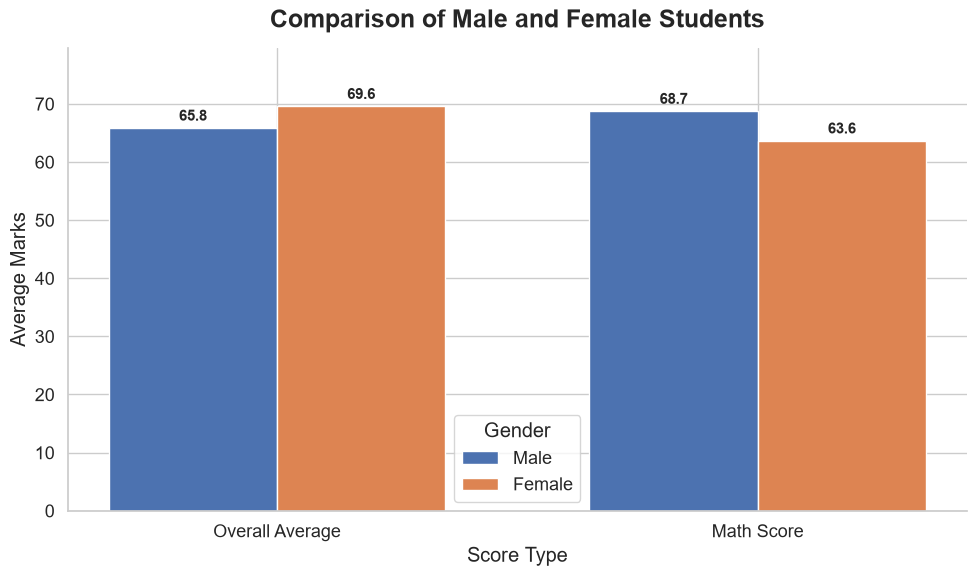

In [ ]:
# Modern theme
sns.set_theme(style="whitegrid", font_scale=1.2)

# Data
metrics = ["Overall Average", "Math Score"]

female_scores = [
    gender_group.loc["female", "average"],
    gender_group.loc["female", "math_score"]
]

male_scores = [
    gender_group.loc["male", "average"],
    gender_group.loc["male", "math_score"]
]

# Positions
x = np.arange(len(metrics))
width = 0.35

# Figure
fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar(
    x - width/2,
    male_scores,
    width,
    label="Male",
    color="#4C72B0"
)

bars2 = ax.bar(
    x + width/2,
    female_scores,
    width,
    label="Female",
    color="#DD8452"
)

# Value labels
for bars in [bars1, bars2]:
    ax.bar_label(
        bars,
        fmt="%.1f",
        padding=3,
        fontsize=11,
        fontweight="bold"
    )

# Labels
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel("Average Marks")
ax.set_xlabel("Score Type")

ax.set_title(
    "Comparison of Male and Female Students",
    fontsize=18,
    fontweight="bold",
    pad=15
)

ax.legend(title="Gender")
ax.set_ylim(0, max(max(male_scores), max(female_scores)) + 10)

sns.despine()

plt.tight_layout()
plt.show()

#### Insights
- On an average females have a better overall score than men.
- whereas males have scored higher in Maths.

#### 4.4.2 RACE/EHNICITY COLUMN
- How is Group wise distribution ?
- Is Race/Ehnicity has any impact on student's performance ?
#### UNIVARIATE ANALYSIS ( How is Group wise distribution ?)

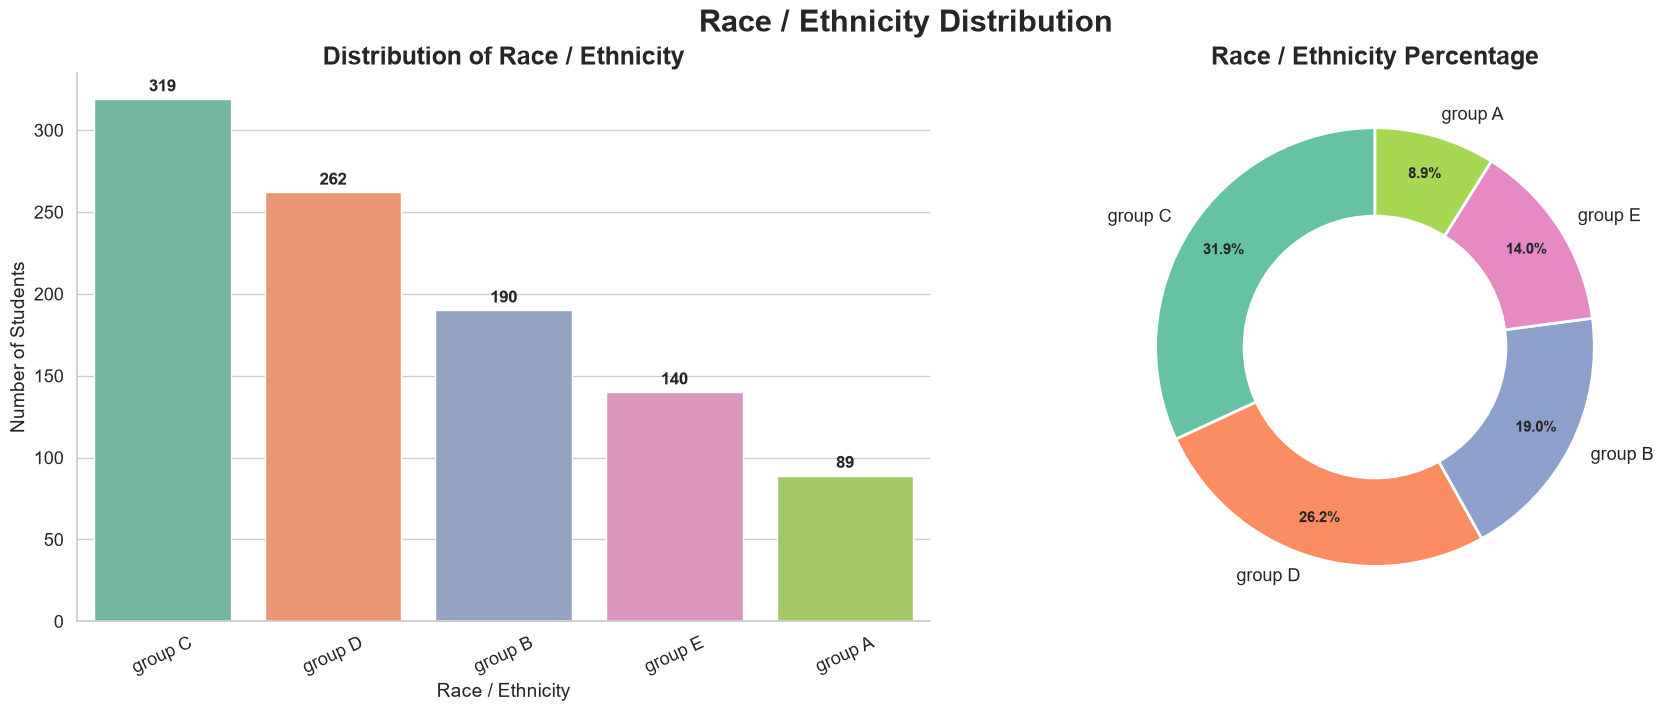

In [ ]:
# Style
sns.set_theme(style="whitegrid", font_scale=1.2)

fig, ax = plt.subplots(1, 2, figsize=(18, 7), constrained_layout=True)

# -------------------------
# Count Plot
# -------------------------
counts = df["race_ethnicity"].value_counts()

sns.countplot(
    data=df,
    x="race_ethnicity",
    order=counts.index,
    palette="Set2",
    ax=ax[0]
)

ax[0].set_title("Distribution of Race / Ethnicity", fontsize=18, fontweight="bold")
ax[0].set_xlabel("Race / Ethnicity", fontsize=14)
ax[0].set_ylabel("Number of Students", fontsize=14)

# Add count labels
for container in ax[0].containers:
    ax[0].bar_label(
        container,
        fontsize=12,
        fontweight="bold",
        padding=3
    )

# Rotate x-axis labels
ax[0].tick_params(axis="x", rotation=25)

# Remove top and right borders
sns.despine(ax=ax[0])

# -------------------------
# Donut Chart
# -------------------------
colors = sns.color_palette("Set2", len(counts))

wedges, texts, autotexts = ax[1].pie(
    counts,
    labels=counts.index,
    colors=colors,
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.82,
    wedgeprops=dict(edgecolor="white", linewidth=2)
)

# Create donut effect
centre_circle = plt.Circle((0, 0), 0.60, fc="white")
ax[1].add_artist(centre_circle)

for autotext in autotexts:
    autotext.set_fontsize(11)
    autotext.set_weight("bold")

ax[1].set_title(
    "Race / Ethnicity Percentage",
    fontsize=18,
    fontweight="bold"
)

plt.suptitle(
    "Race / Ethnicity Distribution",
    fontsize=22,
    fontweight="bold"
)

plt.show()

#### Insights
- Most of the student belonging from group C /group D.
- Lowest number of students belong to group A.

#### BIVARIATE ANALYSIS ( Is Race/Ehnicity has any impact on student's performance ? )

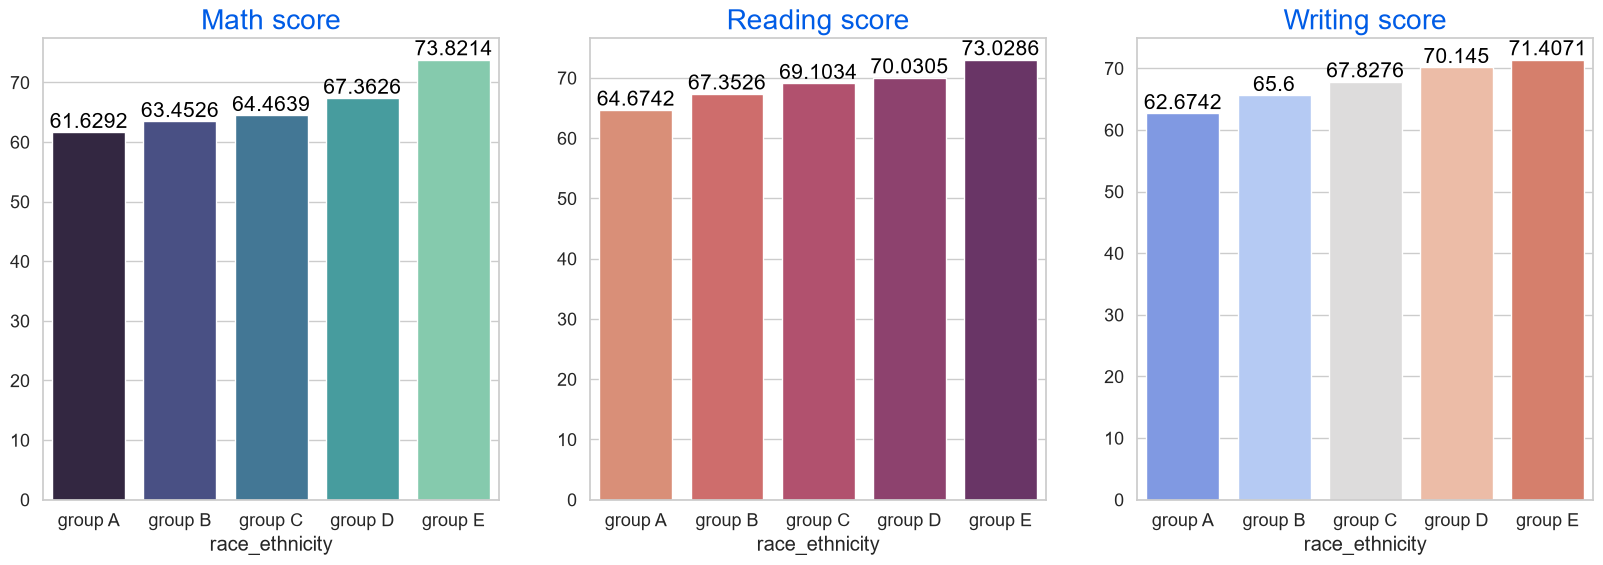

In [101]:
Group_data2=df.groupby('race_ethnicity')
f,ax=plt.subplots(1,3,figsize=(20,6))
sns.barplot(x=Group_data2['math_score'].mean().index,y=Group_data2['math_score'].mean().values,palette = 'mako',ax=ax[0])
ax[0].set_title('Math score',color='#005ce6',size=20)

for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=15)

sns.barplot(x=Group_data2['reading_score'].mean().index,y=Group_data2['reading_score'].mean().values,palette = 'flare',ax=ax[1])
ax[1].set_title('Reading score',color='#005ce6',size=20)

for container in ax[1].containers:
    ax[1].bar_label(container,color='black',size=15)

sns.barplot(x=Group_data2['writing_score'].mean().index,y=Group_data2['writing_score'].mean().values,palette = 'coolwarm',ax=ax[2])
ax[2].set_title('Writing score',color='#005ce6',size=20)

for container in ax[2].containers:
    ax[2].bar_label(container,color='black',size=15)

#### Insights
- Group E students have scored the highest marks.
- Group A students have scored the lowest marks.
- Students from a lower Socioeconomic status have a lower avg in all course subjects

#### 4.4.3 PARENTAL LEVEL OF EDUCATION COLUMN
- What is educational background of student's parent ?
- Is parental education has any impact on student's performance ?
#### UNIVARIATE ANALYSIS ( What is educational background of student's parent ? )

findfont: Failed to find font weight 30, now using 400.


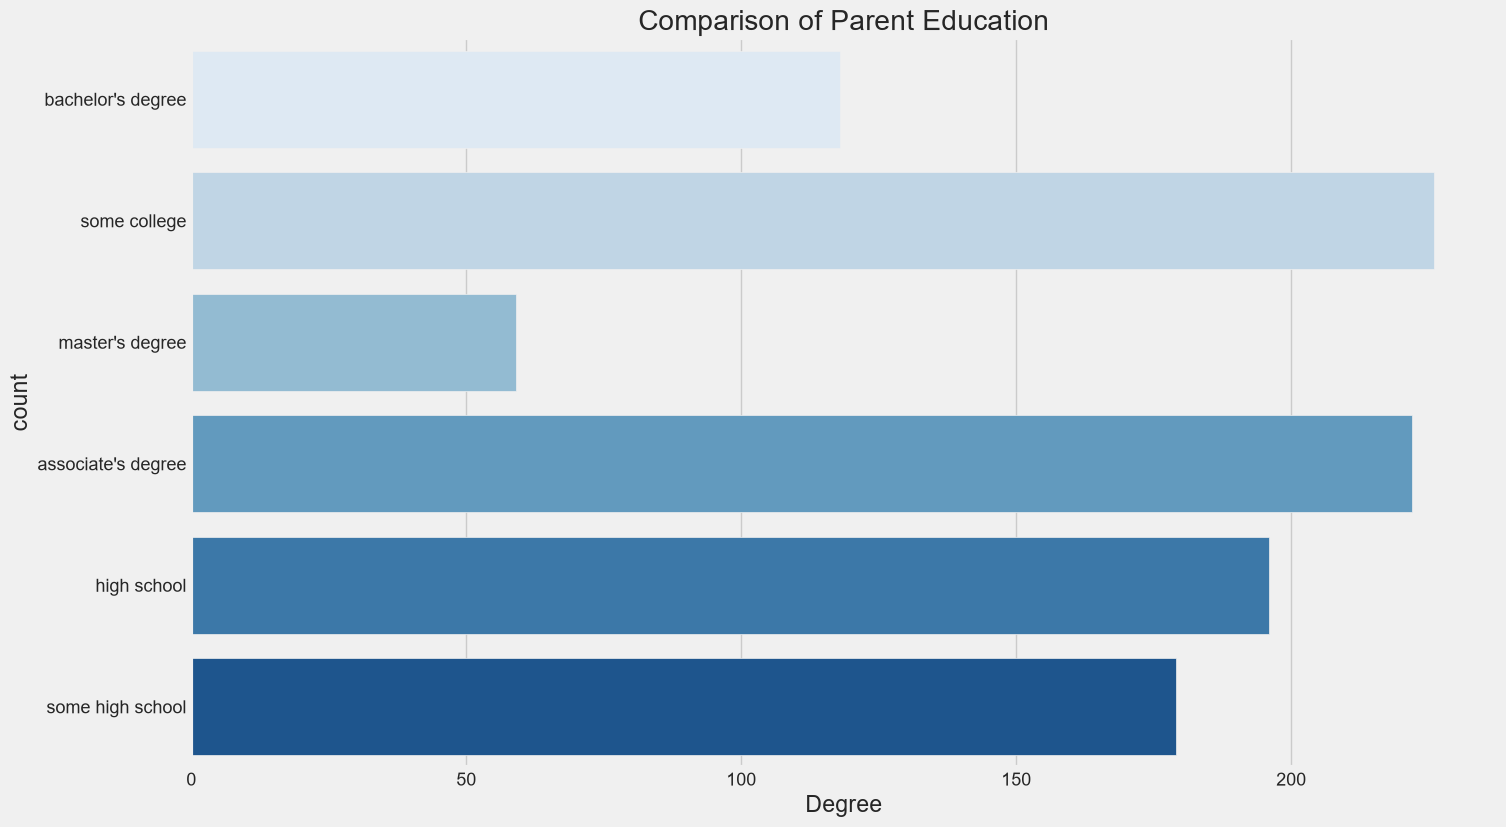

In [103]:
plt.rcParams['figure.figsize'] = (15, 9)
plt.style.use('fivethirtyeight')
sns.countplot(df['parent_education'], palette = 'Blues')
plt.title('Comparison of Parent Education', fontweight = 30, fontsize = 20)
plt.xlabel('Degree')
plt.ylabel('count')
plt.show()

#### Insights
- Largest number of parents are from some college.

#### BIVARIATE ANALYSIS ( Is parental education has any impact on student's performance ? )

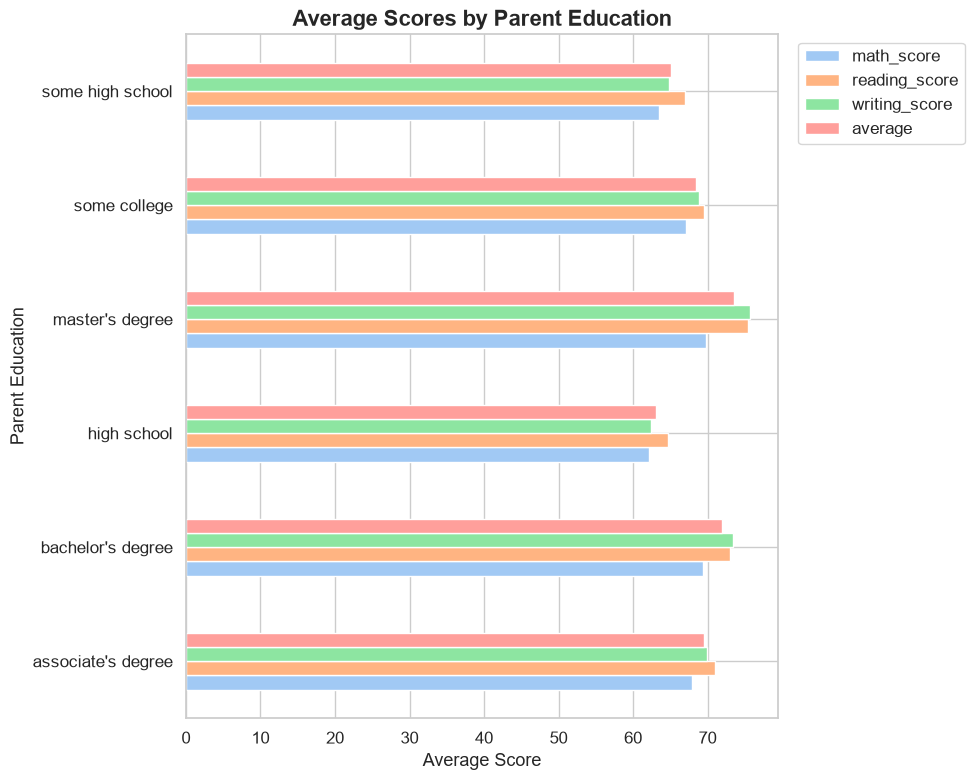

In [122]:
df.groupby("parent_education")[
    ["math_score", "reading_score", "writing_score", "average"]
].mean().plot(
    kind="barh",
    color=sns.color_palette("pastel"),
    figsize=(10, 8)
)

plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xlabel("Average Score")
plt.ylabel("Parent Education")
plt.title("Average Scores by Parent Education", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

#### Insights
- The score of student whose parents possess master and bachelor level education are higher than others.

#### 4.4.4 LUNCH COLUMN
- Which type of lunch is most common amoung students ?
- What is the effect of lunch type on test results?
#### UNIVARIATE ANALYSIS ( Which type of lunch is most common amoung students ? )

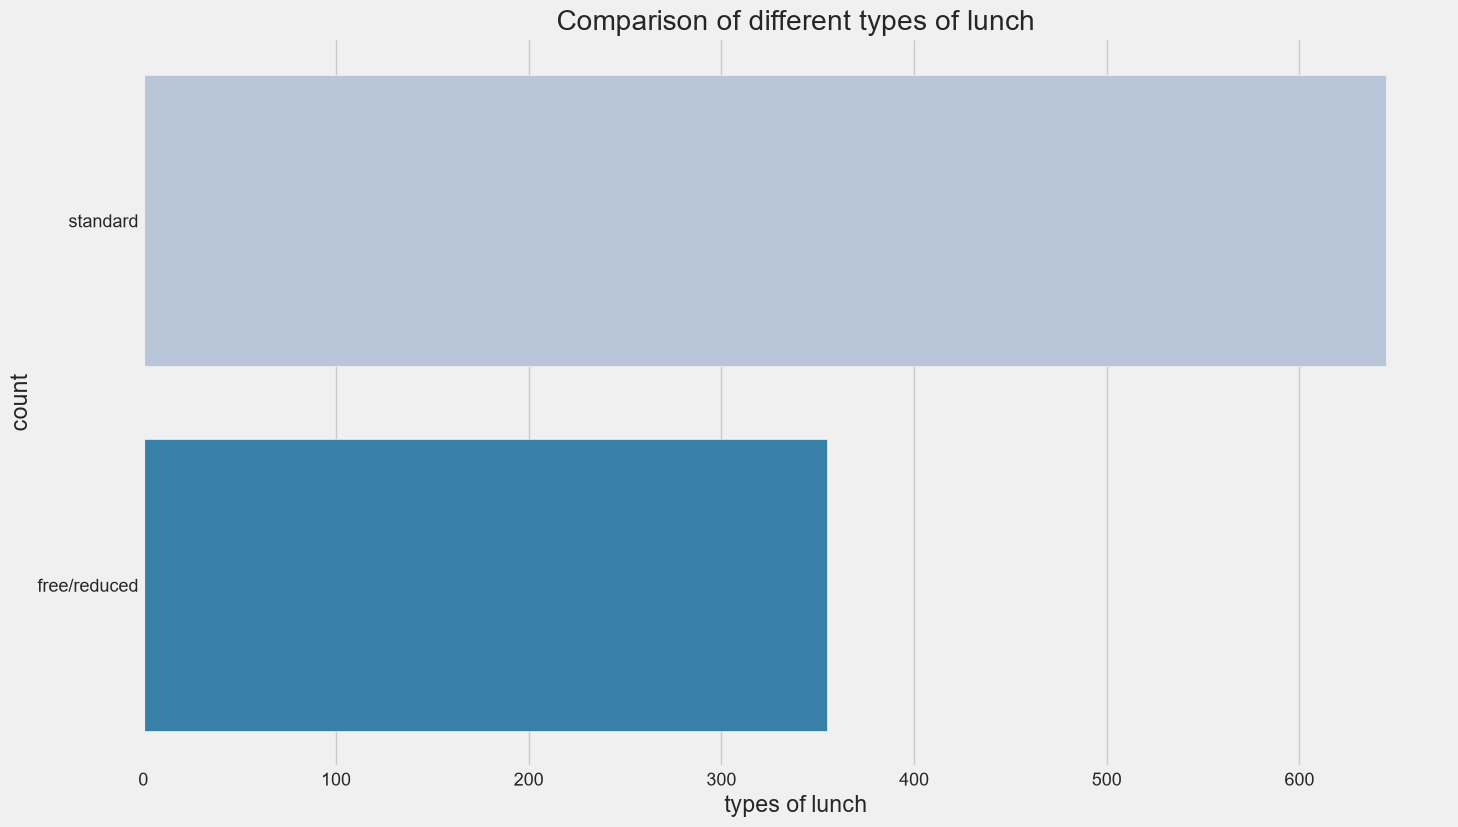

In [ ]:
plt.rcParams['figure.figsize'] = (15, 9)
sns.countplot(df['lunch_type'], palette = 'PuBu')
plt.title('Comparison of different types of lunch', fontweight = 30, fontsize = 20)
plt.xlabel('types of lunch')
plt.ylabel('count')
plt.show()

#### Insights
- Students being served Standard lunch was more than free lunch

#### BIVARIATE ANALYSIS ( Is lunch type intake has any impact on student's performance ? )

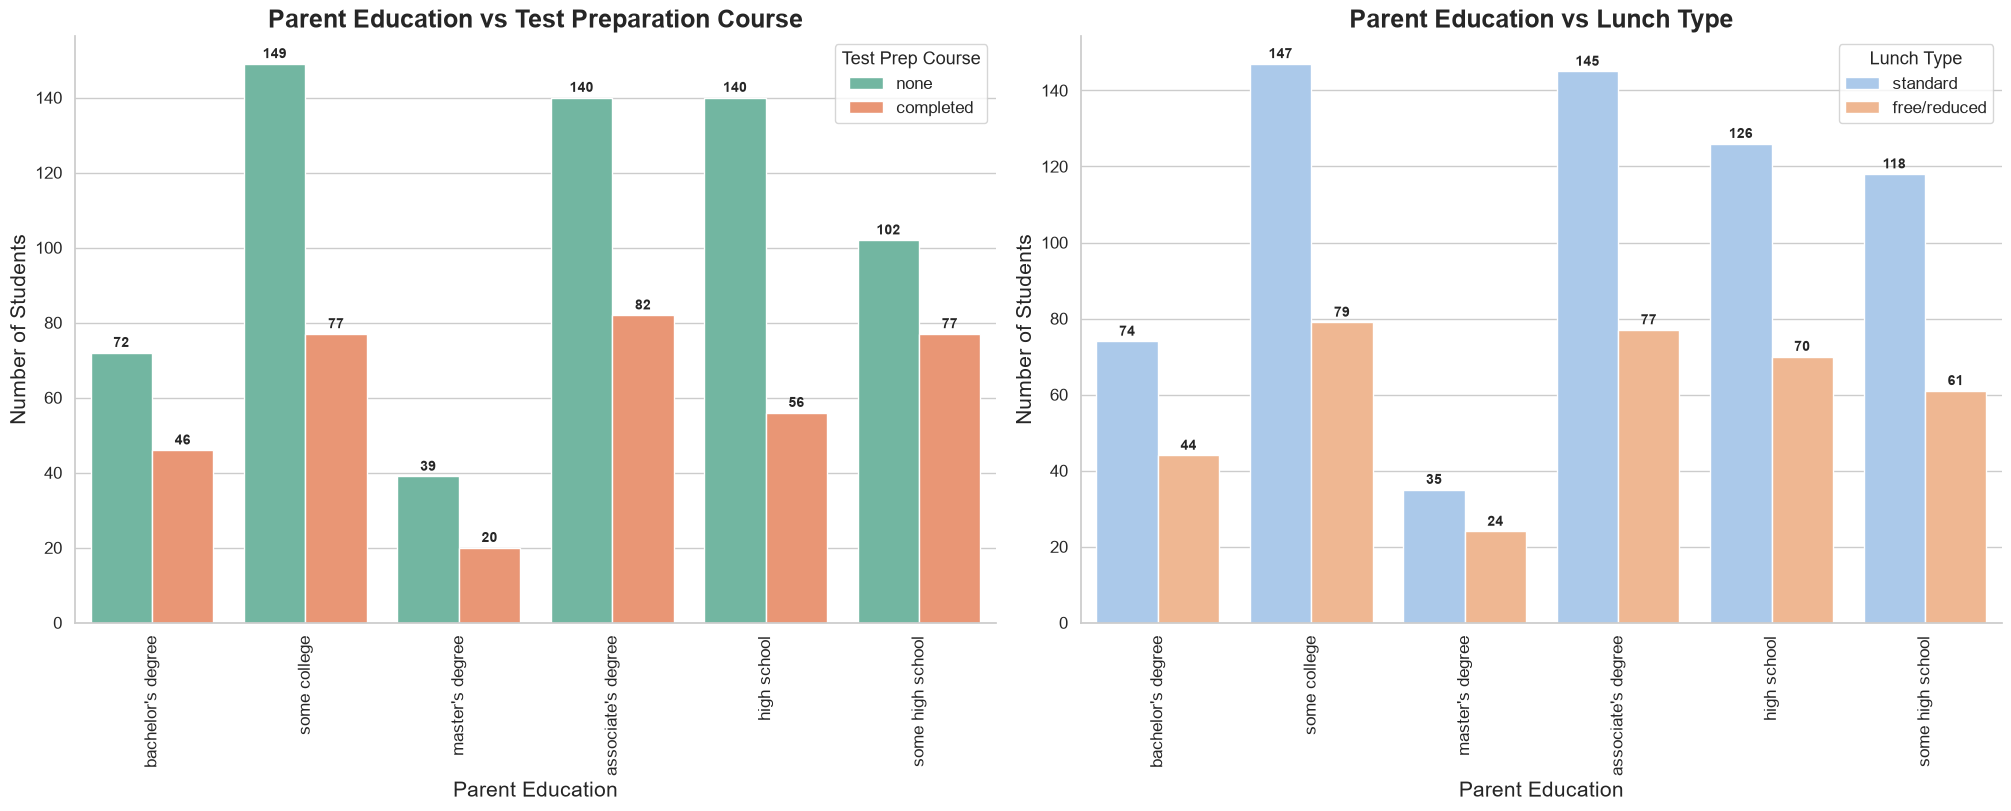

In [ ]:
# Theme
sns.set_theme(style="whitegrid", font_scale=1.1)

fig, ax = plt.subplots(1, 2, figsize=(20, 8), constrained_layout=True)

# -----------------------------
# Parent Education vs Test Prep
# -----------------------------
sns.countplot(
    data=df,
    x="parent_education",
    hue="test_prep_course",
    palette="Set2",
    ax=ax[0]
)

ax[0].set_title(
    "Parent Education vs Test Preparation Course",
    fontsize=18,
    fontweight="bold"
)

ax[0].set_xlabel("Parent Education", fontsize=15)
ax[0].set_ylabel("Number of Students", fontsize=15)

# Rotate x labels
ax[0].tick_params(axis="x", rotation=90)

# Add labels
for container in ax[0].containers:
    ax[0].bar_label(
        container,
        fontsize=10,
        fontweight="bold",
        padding=2
    )

ax[0].legend(title="Test Prep Course")

# -----------------------------
# Parent Education vs Lunch Type
# -----------------------------
sns.countplot(
    data=df,
    x="parent_education",
    hue="lunch_type",
    palette="pastel",
    ax=ax[1]
)

ax[1].set_title(
    "Parent Education vs Lunch Type",
    fontsize=18,
    fontweight="bold"
)

ax[1].set_xlabel("Parent Education", fontsize=15)
ax[1].set_ylabel("Number of Students", fontsize=15)

# Rotate x labels
ax[1].tick_params(axis="x", rotation=90)

# Add labels
for container in ax[1].containers:
    ax[1].bar_label(
        container,
        fontsize=10,
        fontweight="bold",
        padding=2
    )

ax[1].legend(title="Lunch Type")

# Remove unnecessary borders
sns.despine()

plt.show()

#### Insights
- Students who get Standard Lunch tend to perform better than students who got free/reduced lunch

#### 4.4.5 TEST PREPARATION COURSE COLUMN
- Which type of lunch is most common amoung students ?
- Is Test prepration course has any impact on student's performance ?
#### BIVARIATE ANALYSIS ( Is Test prepration course has any impact on student's performance ? )

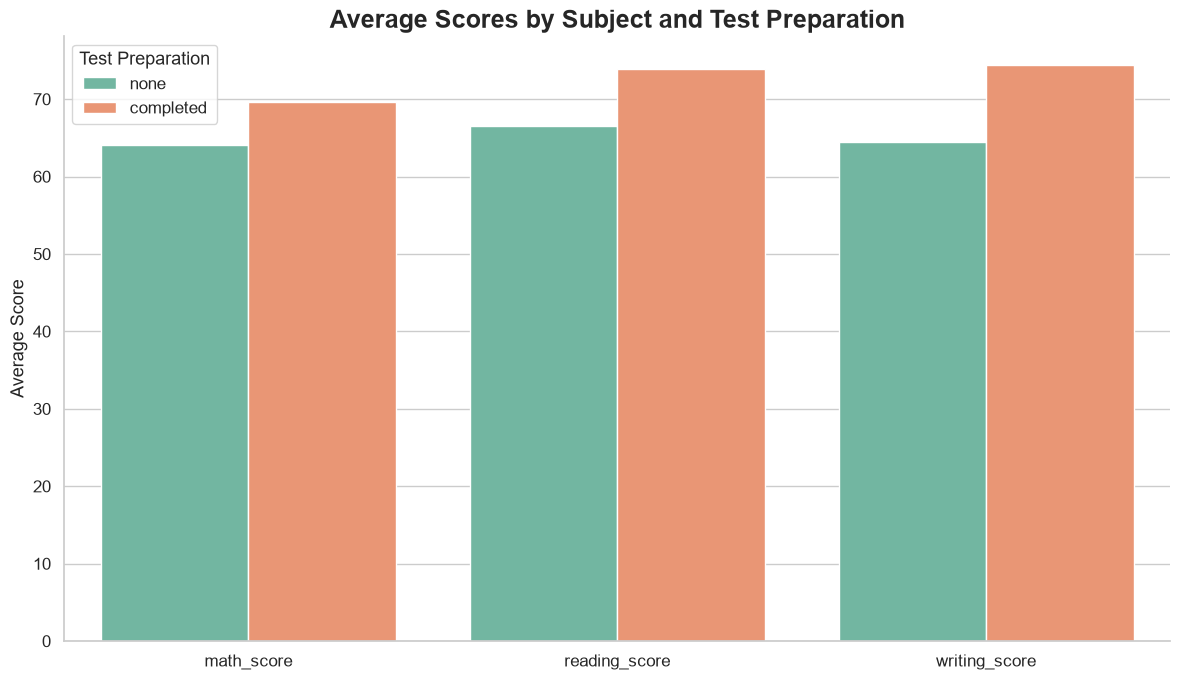

In [126]:
scores = df.melt(
    id_vars=["lunch_type", "test_prep_course"],
    value_vars=["math_score", "reading_score", "writing_score"],
    var_name="Subject",
    value_name="Score"
)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=scores,
    x="Subject",
    y="Score",
    hue="test_prep_course",
    palette="Set2",
    errorbar=None
)

plt.title(
    "Average Scores by Subject and Test Preparation",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("")
plt.ylabel("Average Score")
plt.legend(title="Test Preparation")
sns.despine()
plt.tight_layout()
plt.show()

#### Insights
- Students who have completed the Test Prepration Course have scores higher in all three categories than those who haven't taken the course

#### 4.4.6 CHECKING OUTLIERS

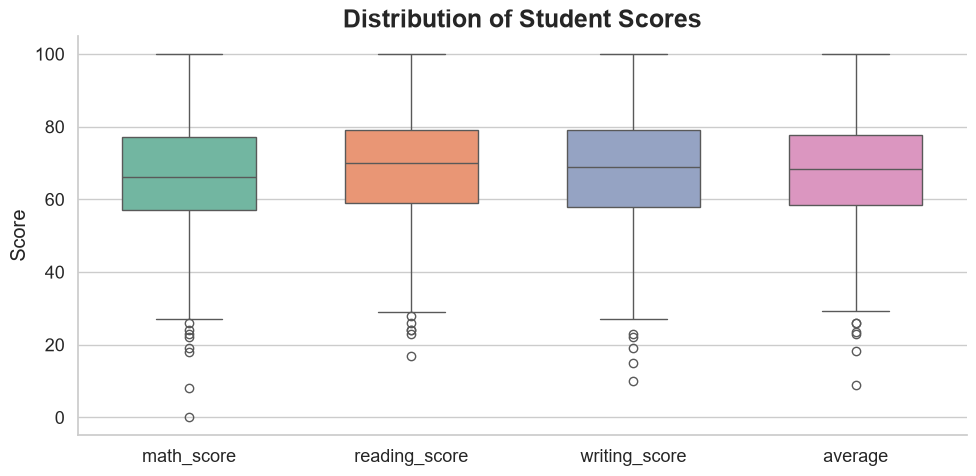

In [137]:
sns.set_theme(style="whitegrid", font_scale=1.2)

scores = df.melt(
    value_vars=["math_score", "reading_score", "writing_score", "average"],
    var_name="Subject",
    value_name="Score"
)

plt.figure(figsize=(10, 5))

sns.boxplot(
    data=scores,
    x="Subject",
    y="Score",
    palette="Set2",
    width=0.6
)

plt.title(
    "Distribution of Student Scores",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("")
plt.ylabel("Score")

sns.despine()
plt.tight_layout()
plt.show()

#### 4.4.7 MUTIVARIATE ANALYSIS USING PAIRPLOT

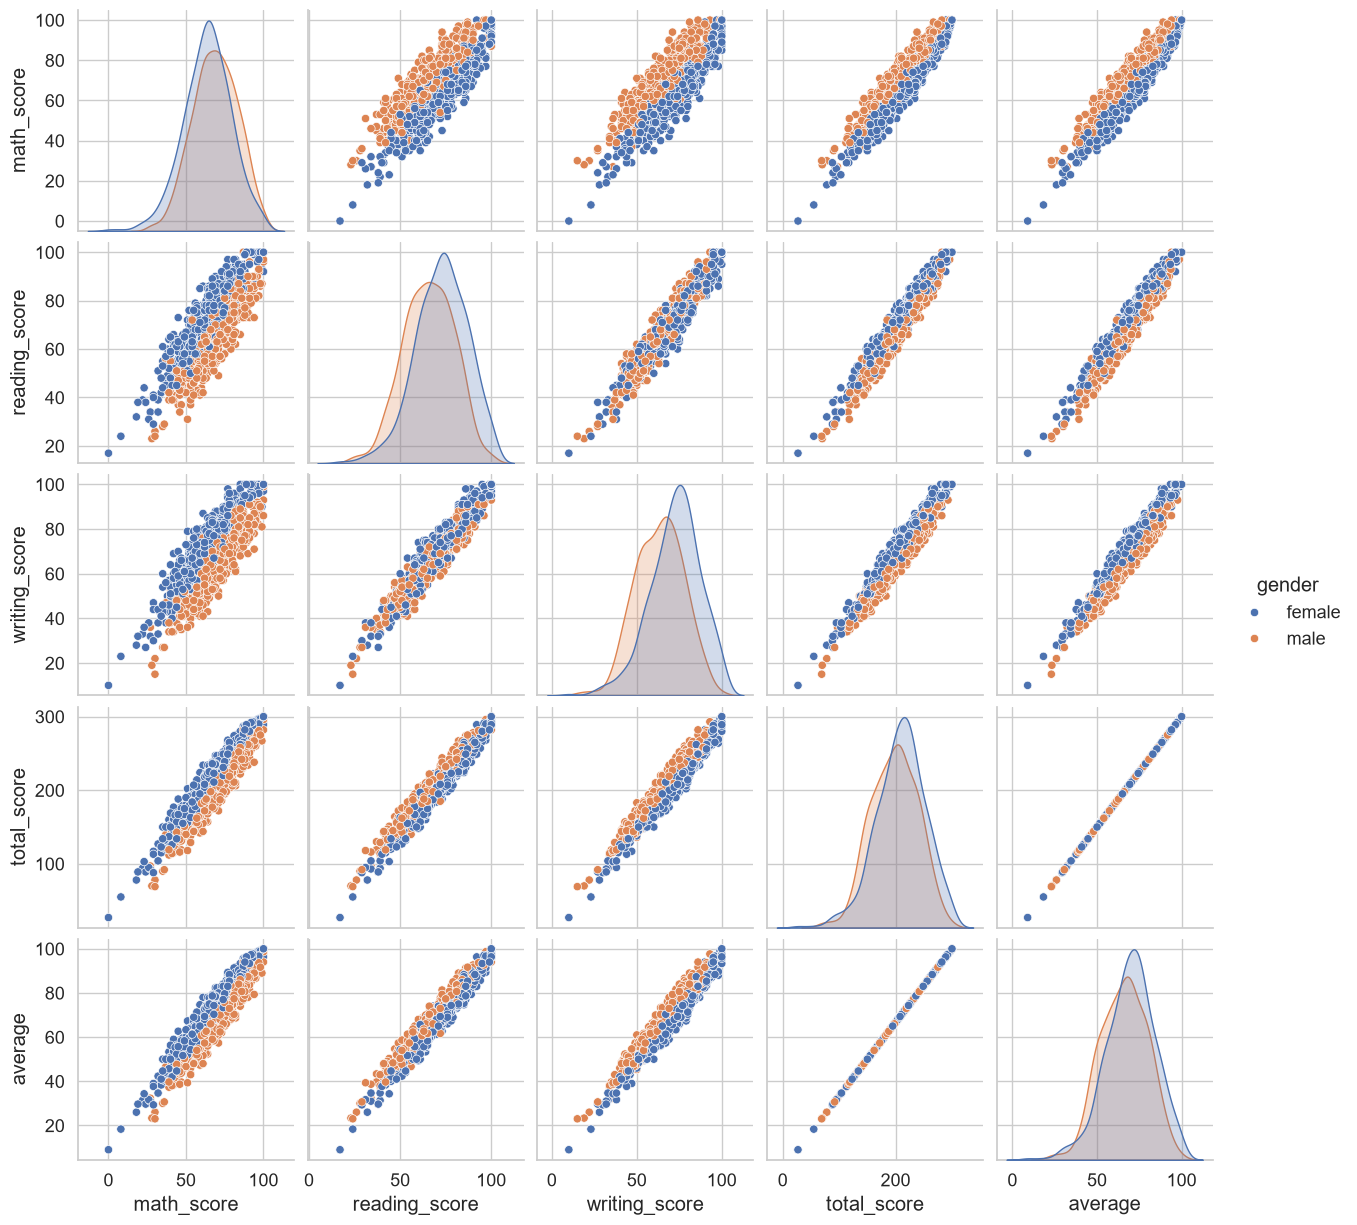

In [136]:
sns.pairplot(df,hue = 'gender')
plt.show()

#### Insights
- From the above plot it is clear that all the scores increase linearly with each other.

## 5. Conclusions
- Student's Performance is related with lunch, race, parental level education
- Females lead in pass percentage and also are top-scorers
- Student's Performance is not much related with test preparation course
- Finishing preparation course is benefitial.